In [1]:
!pip install fastai
from fastai.vision.all import *
print("Ready")

Ready


In [2]:
path = Path('data')
path.mkdir(exist_ok=True)

In [3]:
!wget -q https://raw.githubusercontent.com/Ankur-singh/image_scrapper/refs/heads/master/datasets/bear.txt

In [4]:
!wget -q https://raw.githubusercontent.com/Ankur-singh/image_scrapper/refs/heads/master/datasets/cat.txt

In [5]:
!wget -q https://raw.githubusercontent.com/Ankur-singh/image_scrapper/refs/heads/master/datasets/deer.txt

In [6]:
!wget -q https://raw.githubusercontent.com/Ankur-singh/image_scrapper/refs/heads/master/datasets/dog.txt

In [7]:
download_images('data/bear', Path('bear.txt'))

In [8]:
download_images('data/cat', Path('cat.txt'))

In [9]:
download_images('data/deer', Path('deer.txt'))

In [10]:
download_images('data/dog', Path('dog.txt'))

In [11]:
files = get_image_files(path)
len(files)

441

In [12]:
failed = verify_images(files)
failed

[Path('data/dog/8f47ad16-7749-4b2a-be3b-2a1d06fb9159.jpg'), Path('data/dog/d82e7472-1601-4a9d-8dbf-6cc9f39e1b74.jpg'), Path('data/cat/1fdfa5b2-0a5a-4371-b27e-404508df10b4.jpeg'), Path('data/cat/251b73a8-7f6e-4469-b6aa-9125b08517db.jpg'), Path('data/cat/fcf27a33-9416-4275-817a-34f2aade9a23.jpg'), Path('data/cat/77c2cc2a-9054-4c94-ad02-25513fe0a8b3.jpg'), Path('data/cat/bf3b8692-fd64-49d7-9d33-c1807c83613d.jpg'), Path('data/cat/600cc880-1ab2-4fb8-a901-4f0652c20228.png'), Path('data/cat/0459d5de-5f54-445b-aa08-66bfe45bee07.jpeg'), Path('data/bear/3c7dd146-e532-4124-880e-8c5416b1b10d.jpg'), Path('data/bear/d2618540-3a0b-4835-afb6-44267a29bf3c.jpg'), Path('data/deer/dd1b815c-1a46-4aed-94b7-4a320e68466b.jpg'), Path('data/deer/fe5d93e1-4b0c-4498-90d4-51941abd2e72.jpg'), Path('data/deer/501ba3c1-a0fb-4fe0-84b6-d29459199b01.jpg'), Path('data/deer/c0c42971-851c-42d7-96f9-4d93aa3d8d97.jpg'), Path('data/deer/8df01e9b-5cb6-4fbd-a4b7-aaa44f6bd20b.jpg')]

In [13]:
failed.map(Path.unlink)

[None, None, None, None, None, None, None, None, None, None, None, None, None, None, None, None]

In [14]:
len(files)

441

In [15]:
files = get_image_files(path)
len(files)

425

In [16]:
animals = DataBlock(
    blocks = (ImageBlock, CategoryBlock),

    get_items = get_image_files,

    splitter = RandomSplitter(valid_pct=0.2, seed=42),

    get_y = parent_label,

    item_tfms = RandomResizedCrop(224, min_scale=0.5),

    batch_tfms = aug_transforms()
)

In [17]:
dls = animals.dataloaders(path)

/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


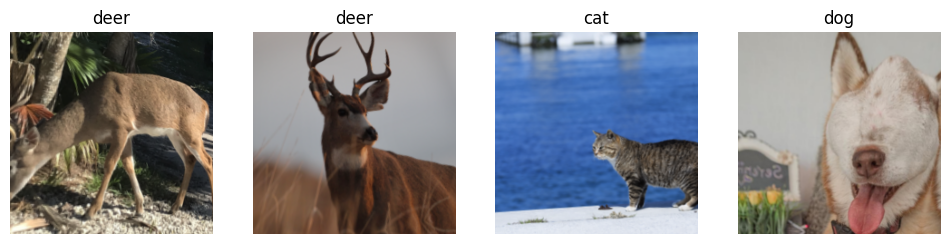

In [18]:
dls.train.show_batch(max_n=4, nrows=1)

A dataloader includes validation and training Dataloaders. Dataloaders is a class that provides batches of a few items at a time to the GPU. When you loop through a dataloader, by default you will get 64 items per batch, all stacked up in a single tensor.


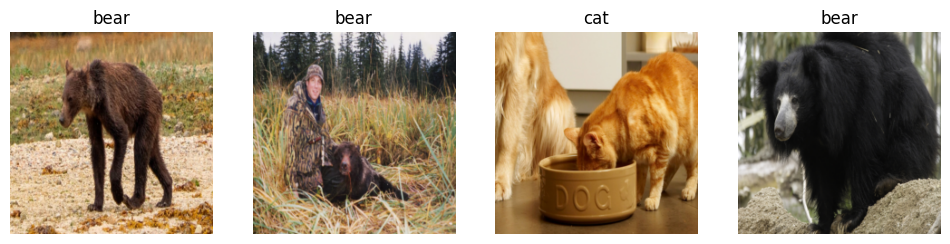

In [19]:
dls.valid.show_batch(max_n=4, nrows=1)

In [20]:
learn = cnn_learner(dls, resnet18, metrics=error_rate)
learn.fine_tune(3)

/usr/local/lib/python3.12/dist-packages/fastai/vision/learner.py:303: UserWarning: `cnn_learner` has been renamed to `vision_learner` -- please update your code
  warn("`cnn_learner` has been renamed to `vision_learner` -- please update your code")


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 55.8MB/s]


epoch,train_loss,valid_loss,error_rate,time
0,1.616024,0.425555,0.141176,00:17


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


epoch,train_loss,valid_loss,error_rate,time
0,0.410256,0.221120,0.070588,00:16
1,0.295529,0.128720,0.058824,00:18
2,0.206400,0.119748,0.058824,00:16


/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/PIL/Image.py:1047: UserWarning: Palette images with Transparency expressed in bytes should be converted to RGBA images
  warnings.warn(


In [21]:
learn.predict(files[10])

('dog', tensor(3), tensor([1.1090e-03, 5.1380e-06, 9.2931e-05, 9.9879e-01]))

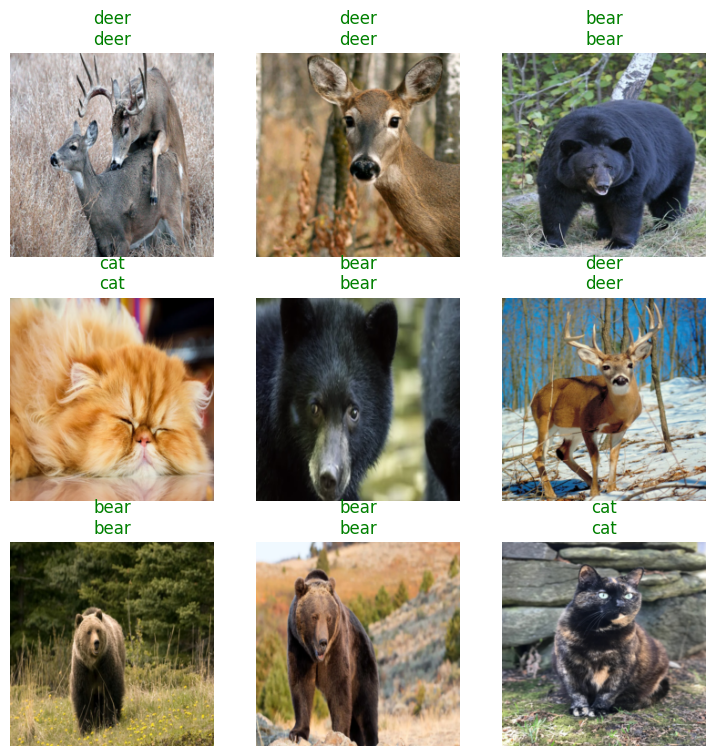

In [22]:
learn.show_results()

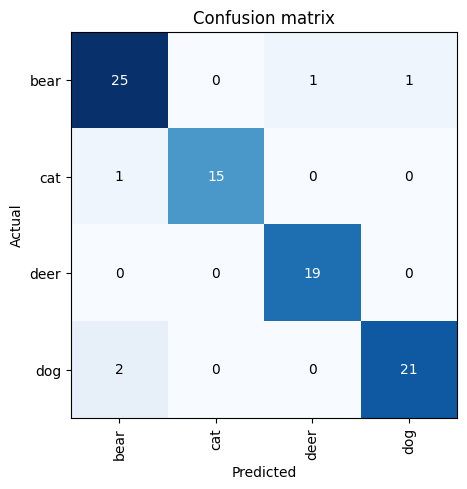

In [30]:
interp = ClassificationInterpretation.from_learner(learn)
interp.plot_confusion_matrix()

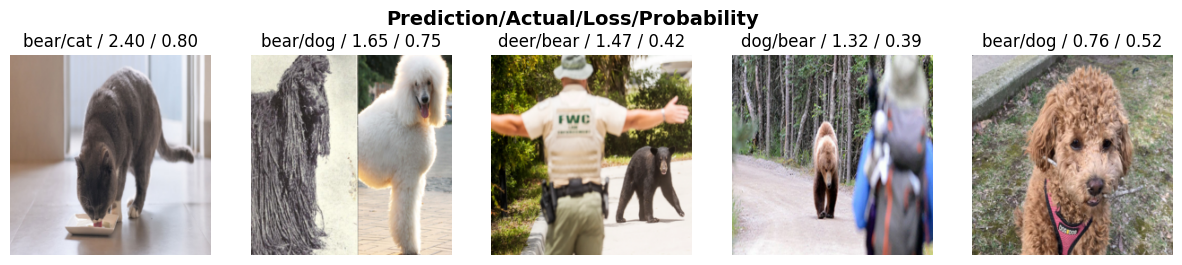

In [31]:
interp.plot_top_losses(5, nrows=1)

In [32]:
learn.export('export.pkl')

In [33]:
!pip install streamlit --q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.2/9.2 MB 25.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.3/11.3 MB 38.3 MB/s eta 0:00:00


In [34]:
!wget -q https://raw.githubusercontent.com/Ankur-singh/image_scrapper/refs/heads/master/streamlit_app.py

In [35]:
!pip install colab-everything